Assignment 11: Image Classification Using Random Forest

## Introduction

This project focuses on image classification using machine learning techniques. The goal is to build a model that can classify images into different categories using a Random Forest Classifier. The dataset used in this assignment contains images from five classes: dalmatian, dollar bill, pizza, soccer ball, and sunflower.

The project includes image loading, resizing, normalization, train-test splitting, Random Forest model training with GridSearchCV, model evaluation, feature importance visualization, prediction on new images, and a bonus comparison with an SVM model.

---



# Step 1: Import Required Libraries

## Step 1: Import Required Libraries

In this step, the required Python libraries are imported to support image processing, data manipulation, visualization, machine learning model training, and evaluation. These libraries will be used throughout the project to implement the image classification pipeline.

In [30]:
# Import required libraries

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC

## Step 2: Extract the Dataset

The dataset is provided as a compressed ZIP file. In this step, the archive is extracted so that all image files become accessible for loading and preprocessing.

In [31]:
# Extract the dataset

zip_path = "images.zip"
extract_path = "images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


## Step 3: Explore the Dataset

Before training the model, it is important to understand the dataset structure. This step identifies the available image classes, counts the number of images in each category, and visualizes the distribution of the dataset.

In [32]:
# Display dataset folders

dataset_path = os.path.join(extract_path, "images")

classes = sorted(os.listdir(dataset_path))

print("Image Classes:")
print(classes)
print("Image Classes:")
print(classes)

Image Classes:
['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']
Image Classes:
['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']


The number of images in each category is calculated to better understand the dataset distribution before training the machine learning model.

In [33]:
# Count images in each class

image_counts = {}

for class_name in classes:
    class_folder = os.path.join(dataset_path, class_name)

    image_counts[class_name] = len(
        [file for file in os.listdir(class_folder)
         if file.lower().endswith(('.jpg', '.jpeg', '.png'))]
    )

counts_df = pd.DataFrame(
    image_counts.items(),
    columns=["Class", "Number of Images"]
)

counts_df

,Class,Number of Images
0,dalmatian,67
1,dollar_bill,51
2,pizza,52
3,soccer_ball,54
4,sunflower,85


The following bar chart shows the number of images available in each class. This helps identify whether the dataset is balanced before training the classifier.

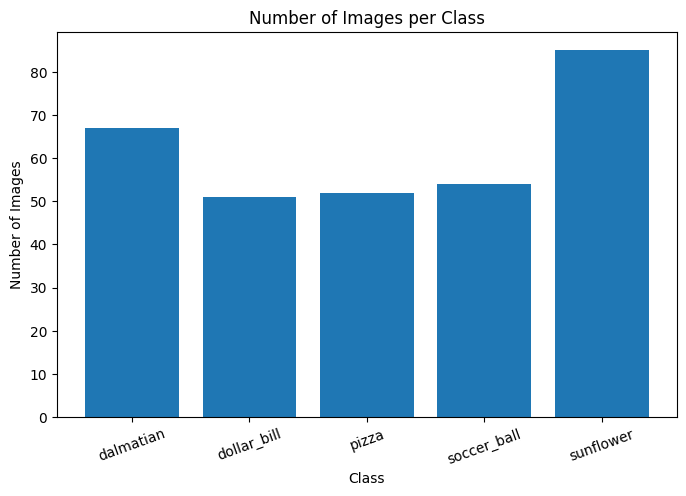

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    counts_df["Class"],
    counts_df["Number of Images"]
)

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=20)

plt.show()

## Step 4: Image Preprocessing

In this step, all images are loaded from the dataset folders and converted into a format suitable for machine learning. Each image is resized to a uniform size, normalized by scaling pixel values to the range of 0 to 1, and converted into a one-dimensional feature vector. The corresponding class labels are also stored for model training.

In [35]:
# Load and preprocess images

image_size = (64, 64)

X = []
y = []

for class_name in classes:

    class_folder = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_folder):

        if file.lower().endswith((".jpg", ".jpeg", ".png")):

            image_path = os.path.join(class_folder, file)

            image = Image.open(image_path)

            image = image.convert("RGB")

            image = image.resize(image_size)

            image = np.array(image)

            image = image / 255.0

            image = image.flatten()

            X.append(image)

            y.append(class_name)

X = np.array(X)
y = np.array(y)

print("Images loaded successfully!")
print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Images loaded successfully!
Feature matrix shape: (309, 12288)
Labels shape: (309,)


The following images provide a quick preview of one sample from each category after loading the dataset.

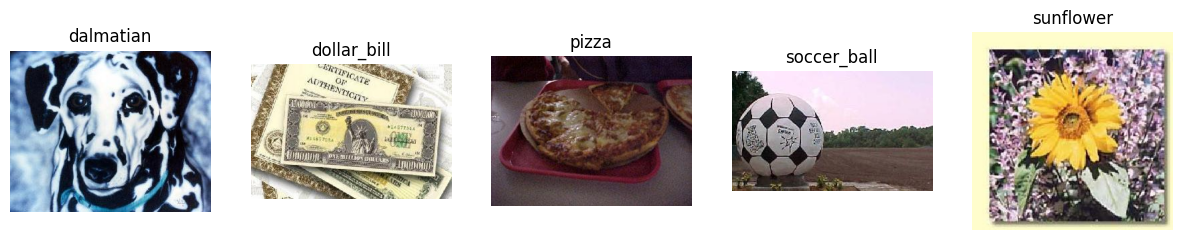

In [36]:
# Display one sample image from each class

plt.figure(figsize=(15,5))

for i, class_name in enumerate(classes):

    class_folder = os.path.join(dataset_path, class_name)

    first_image = os.listdir(class_folder)[0]

    image_path = os.path.join(class_folder, first_image)

    image = Image.open(image_path)

    plt.subplot(1, len(classes), i+1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.show()

## Step 5: Split the Dataset

The dataset is divided into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate how well the trained model performs on unseen images.

In [37]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (247, 12288)
Testing samples: (62, 12288)


## Step 6: Random Forest Model Training

In this step, a Random Forest classifier is trained to classify the images into their corresponding categories. GridSearchCV is used to test different combinations of hyperparameters and automatically select the best-performing model. This helps improve the classification performance compared to using the default settings.

The parameter grid defines the different hyperparameter values that GridSearchCV will evaluate in order to find the best Random Forest model.

In [38]:
# Define the parameter grid

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print(param_grid)

{'n_estimators': [50, 100], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


A Random Forest classifier is created as the base model before applying GridSearchCV.

In [39]:
# Create the Random Forest classifier

rf = RandomForestClassifier(random_state=42)

GridSearchCV evaluates different combinations of hyperparameters using cross-validation and selects the combination that achieves the best performance.

In [ ]:
# Perform Grid Search

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

After evaluating all parameter combinations, GridSearchCV returns the best hyperparameters and the best-performing Random Forest model.

In [ ]:
# Display the best parameters

print("Best Parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

print("\nBest Model:")
print(best_model)

## Step 7: Model Evaluation

The trained Random Forest model is evaluated using the testing dataset. Several evaluation metrics, including accuracy, precision, recall, and F1-score, are calculated to measure the classification performance. A confusion matrix and classification report are also generated to provide detailed insights into the model's predictions.

The trained model is used to predict the classes of the unseen testing images.

In [ ]:
# Make predictions on the test set

y_pred = best_model.predict(X_test)

print("Predictions completed successfully!")

Accuracy measures the percentage of correctly classified images out of all testing images.

In [ ]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

The classification report provides precision, recall, F1-score, and support for each image class.

In [ ]:
# Display the classification report

print("Classification Report:\n")

print(classification_report(y_test, y_pred))

The confusion matrix summarizes the prediction results by comparing the actual classes with the predicted classes.

In [ ]:
# Generate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

The confusion matrix is visualized as a heatmap to better understand the classification performance for each class.

In [ ]:
# Visualize the confusion matrix

plt.figure(figsize=(8,6))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()

plt.show()

## Step 8: Feature Importance Visualization

Random Forest calculates the importance of each feature during the training process. Since each image is represented by thousands of pixel values, only the 20 most important features are visualized to make the results easier to interpret.

The feature importance values are extracted from the trained Random Forest model.

In [ ]:
# Extract feature importance values

feature_importance = best_model.feature_importances_

print("Total Number of Features:", len(feature_importance))

The top 20 most important features are selected for visualization.

In [ ]:
# Select the indices of the top 20 most important features

top_indices = np.argsort(feature_importance)[-20:]

The following chart displays the 20 most important features used by the Random Forest model during classification.

In [ ]:
# Plot the top 20 feature importances

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top_indices)),
    feature_importance[top_indices]
)

plt.title("Top 20 Feature Importances")

plt.xlabel("Feature Index")

plt.ylabel("Importance Score")

plt.xticks(
    range(len(top_indices)),
    top_indices,
    rotation=90
)

plt.tight_layout()

plt.show()

## Step 9: Prediction on New Images

A prediction function is created to classify a new image using the trained Random Forest model. The image undergoes the same preprocessing steps as the training images before making the prediction.

The following function loads a new image, applies the required preprocessing steps, and predicts its class using the trained model.

In [ ]:
# Function to predict a new image

def predict_image(image_path):

    image = Image.open(image_path)

    image = image.convert("RGB")

    image = image.resize(image_size)

    image = np.array(image)

    image = image / 255.0

    image = image.flatten().reshape(1, -1)

    prediction = best_model.predict(image)

    return prediction[0]

A sample image from the dataset is used to test the prediction function.

In [ ]:
# Test the prediction function

sample_image = os.path.join(
    dataset_path,
    "pizza",
    os.listdir(os.path.join(dataset_path, "pizza"))[0]
)

predicted_class = predict_image(sample_image)

print("Predicted Class:", predicted_class)

The selected image and its predicted class are displayed below.

In [ ]:
# Display the sample image

image = Image.open(sample_image)

plt.figure(figsize=(4,4))

plt.imshow(image)

plt.title(f"Predicted Class: {predicted_class}")

plt.axis("off")

plt.show()

## Step 10: SVM Model Comparison (Bonus)

In this step, a Support Vector Machine (SVM) classifier is trained using the same training and testing datasets. The performance of the SVM model is compared with the Random Forest model using the accuracy score.

An SVM classifier is created and trained using the training dataset.

In [ ]:
# Train the SVM model

svm_model = SVC()

svm_model.fit(X_train, y_train)

print("SVM model trained successfully!")

The trained SVM model is evaluated using the testing dataset.

In [ ]:
# Make predictions using SVM

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

The accuracy scores of Random Forest and SVM are compared below.

In [ ]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Random Forest", "SVM"],
    "Accuracy": [accuracy, svm_accuracy]
})

comparison

The following chart compares the accuracy of the Random Forest and SVM models.

In [ ]:
# Visualize model comparison

plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()

## Step 11: Deployment Strategy

The trained Random Forest model can be deployed as a web or mobile application. Users can upload an image, and the system will automatically preprocess it, classify it using the trained model, and display the predicted category. To maintain good performance, the model should be updated and retrained periodically using new image data.

## Step 12: Conclusion

This project successfully demonstrated the complete workflow of image classification using a Random Forest classifier. The images were loaded, resized, normalized, and split into training and testing datasets. GridSearchCV was used to identify the best hyperparameters, and the model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Feature importance visualization and image prediction were also implemented. Finally, the Random Forest model was compared with an SVM model, and the results showed that SVM achieved higher accuracy on this dataset.